In [4]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/NepalStockData/Nepal_Stock_Data/main/Nepse_Data/Manufacturing_And_Processing/SHIVM.csv"

df = pd.read_csv(url)

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date").reset_index(drop=True)

In [3]:
df.head()

,S.N.,Date,Open,High,Low,Ltp,% Change,Qty,Turnover
0,1708,2019-03-24,464.00,464.00,418.00,418.00,0.00,"3,920.00","1,737,870.00"
1,1707,2019-03-25,398.00,398.00,377.00,377.00,-9.81,90.00,"34,350.00"
2,1706,2019-03-26,359.00,359.00,340.00,340.00,-9.81,500.00,"173,150.00"
3,1705,2019-03-27,323.00,350.00,306.00,340.00,0.00,"170,472.00","55,440,896.00"
4,1704,2019-03-28,323.00,353.00,323.00,333.00,-2.06,"78,450.00","26,284,816.00"


In [5]:
df.tail()

,S.N.,Date,Open,High,Low,Ltp,% Change,Qty,Turnover
1703,5,2026-09-14,663.00,675.00,663.00,670.00,1.06,"158,053.00","105,980,691.10"
1704,4,2026-09-15,685.00,690.00,673.00,681.00,1.64,"462,655.00","315,697,044.30"
1705,3,2026-09-16,682.00,687.90,675.00,676.30,-0.69,"243,901.00","165,709,479.50"
1706,2,2026-09-17,685.00,695.00,680.10,685.50,1.36,"396,612.00","272,676,030.80"
1707,1,2026-09-18,686.00,695.00,680.50,688.00,0.36,"259,309.00","178,600,802.60"


In [19]:
#Clean Numeric Columns
num_cols = [
    "Open",
    "High",
    "Low",
    "Ltp",
    "% Change",
    "Qty",
    "Turnover"
]

for col in num_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
    )

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

In [7]:
df.dtypes

S.N.                 int64
Date        datetime64[ns]
Open               float64
High               float64
Low                float64
Ltp                float64
% Change           float64
Qty                float64
Turnover           float64
dtype: object

In [18]:
#Correct Feature Engineering
df["Return_1d"] = df["Ltp"].pct_change(1)
df["Return_5d"] = df["Ltp"].pct_change(5)
df["Return_10d"] = df["Ltp"].pct_change(10)

In [17]:
#Moving-Average Features
df["MA_5"]  =df["Ltp"].rolling(5).mean()
df["MA_20"] = df["Ltp"].rolling(20).mean()

df["Price_MA5_ratio"] = (df["Ltp"] / df["MA_5"])

df["Price_MA20_ratio"] = (df["Ltp"] / df["MA_20"])

In [16]:
#intraday movement
df["Range_pct"] = (
    (df['High'] - df['Low'])
    / df["Open"]
)

df["Open_Close"] = (
    (df['Ltp'] - df['Open'])
    / df['Open']
)

In [20]:
#Volume Features
df["Qty_change"] = df["Qty"].pct_change()

df["Qty_MA5"] = (
    df["Qty"]
    .rolling(5)
    .mean()
)

df["Qty_ratio"] = (
    df["Qty"] /
    df["Qty_MA5"]
)


In [22]:
#Turnover
df['Turnover_change'] = (
    df["Turnover"].pct_change()
)

In [24]:
#Volatility
df["Volatility_5"] = (
    df["Return_1d"]
    .rolling(5)
    .std()
)

df["Volatility_20"] = (
    df["Return_1d"]
    .rolling(20)
    .std()
) #large volatility means market moving aggressively

In [25]:
#Our first tensorflow task is to determine whether, 
#weather price tomorrow will be positive

df["Tomorrow_Return"] = (
    df["Return_1d"].shift(-1)
)

In [26]:
df["Target"] = np.where(
    df["Tomorrow_Return"].isna(),
    np.nan,
    (df["Tomorrow_Return"] > 0).astype(int)
)

In [33]:
df.columns

Index(['S.N.', 'Date', 'Open', 'High', 'Low', 'Ltp', '% Change', 'Qty',
       'Turnover', 'Return_1d', 'Return_5d', 'Return_10d', 'MA_5', 'MA_20',
       'Price_MA5_ratio', 'Price_MA20_ratio', 'Range_pct', 'Open_Close',
       'Qty_change', 'Qty_MA5', 'Qty_ratio', 'Turnover_change', 'Volatility_5',
       'Volatility_20', 'Tomorrow_Return', 'Target'],
      dtype='object')

In [34]:
features = [
    "Return_1d",
    "Return_5d",
    "Return_10d",
    "Price_MA5_ratio",
    "Price_MA20_ratio",
    "Range_pct",
    "Open_Close",
    "Qty_change",
    "Qty_ratio",
    "Turnover_change",
    "Volatility_5",
    "Volatility_20"
]

In [41]:
ml_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1687 entries, 0 to 1686
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              1687 non-null   datetime64[ns]
 1   Return_1d         1687 non-null   float64       
 2   Return_5d         1687 non-null   float64       
 3   Return_10d        1687 non-null   float64       
 4   Price_MA5_ratio   1687 non-null   float64       
 5   Price_MA20_ratio  1687 non-null   float64       
 6   Range_pct         1687 non-null   float64       
 7   Open_Close        1687 non-null   float64       
 8   Qty_change        1687 non-null   float64       
 9   Qty_ratio         1687 non-null   float64       
 10  Turnover_change   1687 non-null   float64       
 11  Volatility_5      1687 non-null   float64       
 12  Volatility_20     1687 non-null   float64       
 13  Tomorrow_Return   1687 non-null   float64       
 14  Target            1687 n

In [36]:
df = df.replace(
    [np.inf, -np.inf],
    np.nan
) #convert infinity into NAN, so it wiill be easier for fillna too.

In [38]:
#creating a tesnsorflow dataset
ml_df = df[
    ["Date"] +
    features +
    ["Tomorrow_Return", "Target"]
].dropna().copy()

ml_df = ml_df.reset_index(drop=True)

In [39]:
print(ml_df.shape)

ml_df.head()

(1687, 15)


,Date,Return_1d,Return_5d,Return_10d,Price_MA5_ratio,Price_MA20_ratio,Range_pct,Open_Close,Qty_change,Qty_ratio,Turnover_change,Volatility_5,Volatility_20,Tomorrow_Return,Target
0,2019-04-22,0.000000,-0.009740,-0.046875,0.993485,0.947794,0.022951,0.000000,0.109051,1.109530,0.114290,0.014045,0.033501,0.016393,1.0
1,2019-04-23,0.016393,-0.003215,-0.057751,1.010430,0.973465,0.019608,0.013072,0.163464,1.180959,0.162250,0.015645,0.027879,-0.009677,0.0
2,2019-04-24,-0.009677,0.006557,-0.009677,0.999349,0.969066,0.019608,0.003268,-0.016302,1.123029,-0.014451,0.013158,0.018485,0.009772,1.0
3,2019-04-25,0.009772,0.003236,0.006494,1.008458,0.983191,0.016340,0.013072,-0.091234,0.990606,-0.082728,0.012479,0.018749,0.045161,1.0
4,2019-04-28,0.045161,0.062295,0.058824,1.041131,1.029061,0.070968,0.045161,1.183607,1.715568,1.286015,0.020840,0.021352,-0.012346,0.0


In [42]:
conda create -n tf-stock python=3.12 -y

Jupyter detected...
3 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - defaults
Platform: win-64
Solving environment: done

## Package Plan ##

  environment location: C:\Users\ashim\anaconda3\envs\tf-stock

  added / updated specs:
    - python=3.12


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.8.13  |       haa95532_0         107 KB
    libexpat-2.8.4             |       hd7fb8db_0         126 KB
    libffi-3.4.8               |       h42d73b9_3         118 KB
    libzlib-1.3.2              |       h1c6eee0_0          63 KB
    openssl-3.5.8              |       hbb43b14_0         8.9 MB
    packaging-26.3             |  py312haa95532_0         374 KB
    pip-26.2.1                 |     pyhc872135_0         1.1 MB
    python-3.12.14             |       hd7b1df3_0        14.7 MB
    setuptools-83.0.0          |  py312haa95532_0         1.



==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.7.2

Please update conda by running

    $ conda update -n base -c defaults conda




In [43]:
conda activate tf-stock


Note: you may need to restart the kernel to use updated packages.


In [47]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [53]:
X = ml_df[features]
y = ml_df["Target"].astype(int)

n = len(ml_df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

In [55]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(1180, 12)
(253, 12)
(254, 12)


In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_val_scaled = scaler.transform(
    X_val
)

X_test_scaled = scaler.transform(
    X_test
) #x_val and x_test only transform not fit to not allow model learn

In [57]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense

In [59]:
model = Sequential([
    
    Input(shape=(len(features),)),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        1,
        activation="relu"
    )
])

In [60]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 961 (3.75 KB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 0 (0.00 B)

In [65]:
Dense(
    32,
    activation="relu"
)
# 12 input features ---> 32 artificial neurons

<Dense name=dense_4, built=False>

In [69]:
#which final layer has only one neuron
Dense(
    1,
    activation="sigmoid"
)

<Dense name=dense_6, built=False>

In [70]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="binary_crossentropy",

    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(
            name="auc"
        ),
        tf.keras.metrics.Precision(
            name="precision"
        ),
        tf.keras.metrics.Recall(
            name="recall"
        )
    ]
)

In [74]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [71]:
#Training the Model First
history = model.fit(
    X_train_scaled,
    y_train,

    validation_data=(
        X_val_scaled,
        y_val
    ),

    epochs=100,

    batch_size=32,

    shuffle=False,

    verbose=1
)

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.5542 - auc: 0.5145 - loss: 1.6952 - precision: 0.4533 - recall: 0.2731 - val_accuracy: 0.5059 - val_auc: 0.4693 - val_loss: 1.1984 - val_precision: 0.3611 - val_recall: 0.2476
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5492 - auc: 0.5326 - loss: 0.9999 - precision: 0.4506 - recall: 0.3112 - val_accuracy: 0.5375 - val_auc: 0.5002 - val_loss: 0.8351 - val_precision: 0.4388 - val_recall: 0.4095
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5475 - auc: 0.5362 - loss: 0.8618 - precision: 0.4375 - recall: 0.2530 - val_accuracy: 0.5415 - val_auc: 0.5204 - val_loss: 0.7435 - val_precision: 0.4466 - val_recall: 0.4381
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5517 - auc: 0.5434 - loss: 0.8330 - precision: 0.4456 - recall: 0.2550 - val_accuracy: 0.5257 - val_auc: 0.5286 - val_loss: 0.7345 - val_precision: 0.4312 - val_recall: 0.4476
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━

In [72]:
#Using Early Stopper
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [75]:
history = model.fit(
    X_train_scaled,
    y_train,

    validation_data=(
        X_val_scaled,
        y_val
    ),

    epochs=200,

    batch_size=32,

    callbacks=[
        early_stop
    ],

    shuffle=False,
    verbose=1
)

Epoch 1/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7034 - auc: 0.7734 - loss: 0.5792 - precision: 0.6937 - recall: 0.5321 - val_accuracy: 0.5099 - val_auc: 0.5373 - val_loss: 0.8327 - val_precision: 0.4112 - val_recall: 0.4190
Epoch 2/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7059 - auc: 0.7741 - loss: 0.5782 - precision: 0.6961 - recall: 0.5382 - val_accuracy: 0.5099 - val_auc: 0.5366 - val_loss: 0.8333 - val_precision: 0.4128 - val_recall: 0.4286
Epoch 3/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7076 - auc: 0.7755 - loss: 0.5771 - precision: 0.6997 - recall: 0.5382 - val_accuracy: 0.5099 - val_auc: 0.5355 - val_loss: 0.8345 - val_precision: 0.4128 - val_recall: 0.4286
Epoch 4/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7085 - auc: 0.7765 - loss: 0.5760 - precision: 0.6995 - recall: 0.5422 - val_accuracy: 0.5178 - val_auc: 0.5366 - val_loss: 0.8352 - val_precision: 0.4220 - val_recall: 0.4381
Epoch 5/200
37/37 ━━━━━━━━━━━━━━━━━

In [76]:
restore_best_weights=True

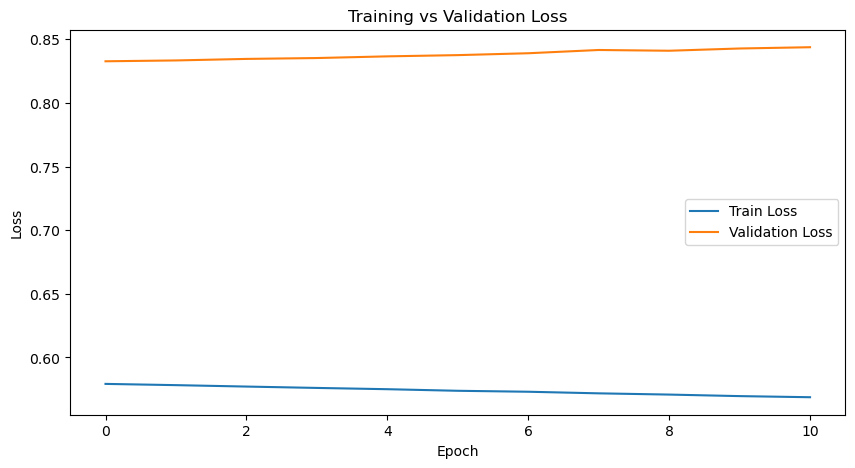

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

In [79]:
#evaluate the test set
test_results = model.evaluate(
    X_test_scaled,
    y_test
)

print(test_results)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5394 - auc: 0.5591 - loss: 0.8445 - precision: 0.4762 - recall: 0.3540
[0.8444812297821045, 0.539370059967041, 0.5590911507606506, 0.4761904776096344, 0.3539822995662689]


In [80]:
probabilities = model.predict(
    X_test_scaled
).ravel()

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [81]:
probabilities[:10]

array([0.4115771 , 0.47394726, 0.5535032 , 0.41699228, 0.23710975,
       0.5475457 , 0.33653876, 0.3624053 , 0.39462575, 0.49288675],
      dtype=float32)

In [82]:
predictions = (
    probabilities >= 0.5
).astype(int)

In [84]:
#This is very very important to understand

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        predictions
    )
)

print(
    "AUC:",
    roc_auc_score(
        y_test,
        probabilities
    )
)

print(
    classification_report(
        y_test,
        predictions
    )
)

print(
    confusion_matrix(
        y_test,
        predictions
    )
)

Accuracy: 0.5393700787401575
AUC: 0.5594677712922864
              precision    recall  f1-score   support

           0       0.57      0.69      0.62       141
           1       0.48      0.35      0.41       113

    accuracy                           0.54       254
   macro avg       0.52      0.52      0.51       254
weighted avg       0.53      0.54      0.53       254

[[97 44]
 [73 40]]


In [86]:
#Improve the Dense neural network by adding dropout
from tensorflow.keras.layers import Dropout

model = Sequential([

    Input(
        shape=(len(features),)
    ),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.20),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.20),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

In [87]:
reduce_lr = (
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6
    )
)

In [91]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [92]:
history = model.fit(
    X_train_scaled,
    y_train,

    validation_data=(
        X_val_scaled,
        y_val
    ),

    epochs=200,

    batch_size=32,

    callbacks=[
        early_stop,
        reduce_lr
    ],

    shuffle=False
)



Epoch 1/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.2484 - mae: 0.4950 - val_loss: 0.2462 - val_mae: 0.4945 - learning_rate: 0.0010
Epoch 2/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2458 - mae: 0.4910 - val_loss: 0.2450 - val_mae: 0.4918 - learning_rate: 0.0010
Epoch 3/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2450 - mae: 0.4873 - val_loss: 0.2445 - val_mae: 0.4901 - learning_rate: 0.0010
Epoch 4/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2430 - mae: 0.4850 - val_loss: 0.2437 - val_mae: 0.4891 - learning_rate: 0.0010
Epoch 5/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2414 - mae: 0.4829 - val_loss: 0.2436 - val_mae: 0.4894 - learning_rate: 0.0010
Epoch 6/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2401 - mae: 0.4821 - val_loss: 0.2446 - val_mae: 0.4899 - learning_rate: 0.0010
Epoch 7/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2428 - mae: 0.4837 - val_loss: 0.2449 - val_mae: 0.4899 - learning_rate: 0.0010
Epoch 8/20

In [93]:
y = ml_df[
    "Tomorrow_Return"
]

In [94]:
print(y)

0       0.016393
1      -0.009677
2       0.009772
3       0.045161
4      -0.012346
          ...   
1682    0.010558
1683    0.016418
1684   -0.006902
1685    0.013603
1686    0.003647
Name: Tomorrow_Return, Length: 1687, dtype: float64


In [96]:
# Create a 20 days sequence
WINDOW = 20

def make_sequences(
    X,
    y,
    window=20
):

    X_seq = []
    y_seq = []

    for end in range(
        window - 1,
        len(X)
    ):

        start = (
            end -
            window +
            1
        )

        X_seq.append(
            X[start:end + 1]
        )

        y_seq.append(
            y[end]
        )

    return (
        np.array(X_seq),
        np.array(y_seq)
    )

In [97]:
n = len(ml_df)

train_end = int(
    n * 0.70
)

val_end = int(
    n * 0.85
)

X_all = ml_df[
    features
].values

y_all = ml_df[
    "Target"
].astype(int).values

In [98]:
scaler = StandardScaler()

scaler.fit(
    X_all[:train_end]
)

X_scaled = scaler.transform(
    X_all
)